This project aims to develop a machine learning system that recommends the most suitable crop to grow and predicts crop yield based on environmental factors, including weather, rainfall, and climate.

#### Import libraries

In [275]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


#### Load datasets

In [230]:
df_soil = pd.read_csv('../data/texas.csv')
df_weather = pd.read_csv('../data/texas_weather_2025.csv')

In [231]:
df_soil.head()

,areasymbol,musym,muname,compname,saverest,taxorder,drainagecl,elev_r,slope_r,hzdept_r,hzdepb_r,ph1to1h2o_r,om_r,ec_r,cec7_r,awc_r,cropname,yldunits,nonirryield_r,irryield_r
0,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Alfalfa hay,Tons,3.0,6.0
1,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Cotton lint,Lbs,225.0,600.0
2,TX129,SfD,"Springer fine sandy loam, 5 to 8 percent slopes",Springer,9/4/2025 7:20:13 PM,Alfisols,Well drained,610.0,7.0,0,41,7.0,0.5,1.0,11.7,0.10,Grain sorghum,Bu,25.0,75.0
3,TX129,AlA,"Altus fine sandy loam, dry, 0 to 1 percent slopes",Altus,9/4/2025 7:20:13 PM,Mollisols,Well drained,662.9,0.5,0,25,6.6,1.5,0.0,9.8,0.13,Grain sorghum,Bu,50.0,NaN
4,TX129,AlA,"Altus fine sandy loam, dry, 0 to 1 percent slopes",Altus,9/4/2025 7:20:13 PM,Mollisols,Well drained,662.9,0.5,0,25,6.6,1.5,0.0,9.8,0.13,Improved bermudagrass,AUM,6.0,NaN


In [232]:
df_soil.columns

Index(['areasymbol', 'musym', 'muname', 'compname', 'saverest', 'taxorder',
       'drainagecl', 'elev_r', 'slope_r', 'hzdept_r', 'hzdepb_r',
       'ph1to1h2o_r', 'om_r', 'ec_r', 'cec7_r', 'awc_r', 'cropname',
       'yldunits', 'nonirryield_r', 'irryield_r'],
      dtype='str')

#### Features
* We drop areasymbol because the is identification of the area. That does not have meaning itself.
* We drop musym and muname because taxorder indicates the soil type more briefly than those. They are too specifi to use.
* We drop saverest because this is updated data and all are updated in Sepetember in 2025.
* We drop hzdept because all values in this column is 0.

| Column | Description | Usage |
| --- | --- | --- |
| areasymbol | A unique code that identifies a specific soil survey area | Drop |
| musym | A short unique identifier used to label a specific map unit within a single soil survey area | Drop |
| muname | The full, formal name of the soil unit | Drop |
| compname | Name of soil component, very specific than taxorder | Feature |
| saverest | Time stamp represent the exact date and time of soil data | Drop |
| taxorder | The highest level in Soil Taxonomy or Soil type| Feature |
| drainagecl | Drainage class | Feature |
| elev_r | Altitude or elevation | Feature |
| slope_r | Slope | Feature |
| hzdept_r | The distance from the top of the soil surface to the upper boundary of a specific soil horizon | Drop |
| hzdepb_r | The distance from the top of the soil surface to the lower boundary of a specific soil horizon | Feature |
| ph1to1h2o_r | pH | Feature |
| om_r | Nutrient | Feature |
| ec_r | EC (electrical Conductivity) | Feature |
| cec7_r | CEC (Cation Exchange Capacity) | Feature
| awc_r | AWC (Available Water Capacity) | Feature
| cropname | The name of crops | Target for crop recommendation |
| yldunits | Crop yield units per unit area for the specified crop | Use when standardizeing the crop yield |
| nonirryield_r | The expected yield per acre of the specific crop without irrigation | Target for crop yield prediction |
| irryield_r | The expected yield per acre of the specific crop with irrigation | Target for crop yield prediction |


https://docs.google.com/document/d/1hZgvWIYF03py2quTsW1hpOCYE-pO2eVkZ7HLiCrpQ7E/edit?tab=t.0

In [233]:
df_soil = df_soil.drop(
    ['areasymbol', 
    'musym', 
    'muname', 
    'saverest', 
    'hzdept_r', 
    'nonirryield_r', 
    'irryield_r'], 
    axis=1
    )

In [234]:
df_soil.columns

Index(['compname', 'taxorder', 'drainagecl', 'elev_r', 'slope_r', 'hzdepb_r',
       'ph1to1h2o_r', 'om_r', 'ec_r', 'cec7_r', 'awc_r', 'cropname',
       'yldunits'],
      dtype='str')

In [235]:
df_soil.head()

,compname,taxorder,drainagecl,elev_r,slope_r,hzdepb_r,ph1to1h2o_r,om_r,ec_r,cec7_r,awc_r,cropname,yldunits
0,Springer,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,Alfalfa hay,Tons
1,Springer,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,Cotton lint,Lbs
2,Springer,Alfisols,Well drained,610.0,7.0,41,7.0,0.5,1.0,11.7,0.10,Grain sorghum,Bu
3,Altus,Mollisols,Well drained,662.9,0.5,25,6.6,1.5,0.0,9.8,0.13,Grain sorghum,Bu
4,Altus,Mollisols,Well drained,662.9,0.5,25,6.6,1.5,0.0,9.8,0.13,Improved bermudagrass,AUM


#### Explore the dataset

In [236]:
print(df_soil.shape)
print(df_soil.info())
print(df_soil.describe())

(49146, 13)
<class 'pandas.DataFrame'>
RangeIndex: 49146 entries, 0 to 49145
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   compname     49146 non-null  str    
 1   taxorder     48222 non-null  str    
 2   drainagecl   48499 non-null  str    
 3   elev_r       49112 non-null  float64
 4   slope_r      49146 non-null  float64
 5   hzdepb_r     49146 non-null  int64  
 6   ph1to1h2o_r  48413 non-null  float64
 7   om_r         48349 non-null  float64
 8   ec_r         48415 non-null  float64
 9   cec7_r       44311 non-null  float64
 10  awc_r        48412 non-null  float64
 11  cropname     45004 non-null  str    
 12  yldunits     44999 non-null  str    
dtypes: float64(7), int64(1), str(5)
memory usage: 4.9 MB
None
             elev_r      slope_r      hzdepb_r   ph1to1h2o_r          om_r  \
count  49112.000000  49146.00000  49146.000000  48413.000000  48349.000000   
mean     385.182768      2.78738     28.7

#### Missing values

In [237]:
# Count missing values
print(df_soil.isnull().sum())

compname          0
taxorder        924
drainagecl      647
elev_r           34
slope_r           0
hzdepb_r          0
ph1to1h2o_r     733
om_r            797
ec_r            731
cec7_r         4835
awc_r           734
cropname       4142
yldunits       4147
dtype: int64


In [238]:
# Drop null values in cropname (target variable)
df_soil = df_soil.dropna(subset=['cropname'])

# Count missing values
print(df_soil.isnull().sum())

compname          0
taxorder          2
drainagecl        0
elev_r            0
slope_r           0
hzdepb_r          0
ph1to1h2o_r      11
om_r             11
ec_r              9
cec7_r         3864
awc_r            11
cropname          0
yldunits          5
dtype: int64


#### Number of unique values

In [239]:
# Number of unique values
df_soil.nunique()

compname       1162
taxorder          7
drainagecl        7
elev_r          782
slope_r          52
hzdepb_r        110
ph1to1h2o_r      46
om_r            112
ec_r             36
cec7_r          355
awc_r            25
cropname         49
yldunits          7
dtype: int64

# --- For prediction ---

#### Stadardize crop yield

In [240]:
df_soil['yldunits'].unique()

<StringArray>
['Tons', 'Lbs', 'Bu', 'AUM', 'Sacks', 'Boxes', nan, 'Crates']
Length: 8, dtype: str

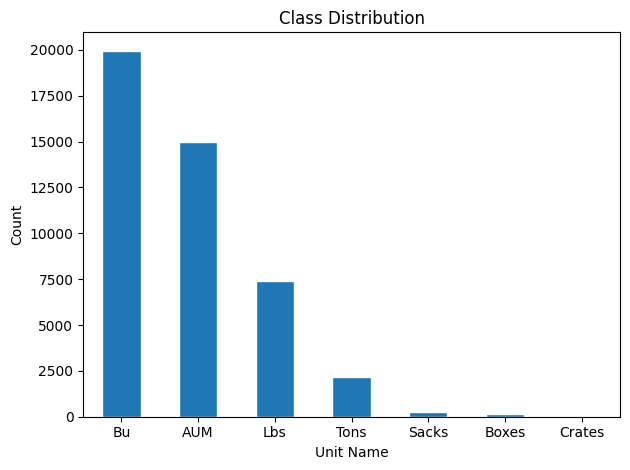

In [241]:
df_soil['yldunits'].value_counts().plot(
    kind='bar',
    edgecolor='white', 
    width=0.5
)

plt.xticks(rotation=0)
plt.title('Class Distribution', fontsize=12)
plt.xlabel('Unit Name')
plt.ylabel('Count')


plt.tight_layout()
plt.show()

* Weight (Tons, Lbs)
* Volume (Bu, Sacks, Boxes, Crates)
* Carrying capacity (AUM)

Since units measure different things, we cannot standardize all of them across the category. For example we cannot convert Boxes to Lbs because a "Box" of oranges doesn't weigh the same as a "Box" of strawberries. 

https://www.grainunitconverter.com/\
In USDA, a sack is almost equivalent to CWT
We arbitrarily set the conversion rate.
Standardize Lbs
| Crop | Unit | Lb |
| --- | --- | --- |
| Anything | 1 US ton | 2000 lbs |
| Grain sorghum | 1 Bu | 56 lbs |
| Corn | 1 Bu | 56 lbs |
| Wheat/Winter wheat | 1 Bu | 60 lbs |
| Oats | 1 Bu | 34 lbs |
| Peaches | 1 Bu | 48 lbs?|
| Soybeans | 1 Bu | 60 lbs |
| Green peas | 1 Bu | 60 lbs |
| Flax | 1 Bu | 56 lbs |
| Rye | 1 Bu | 56 lbs |
| Rice | 1 Bu | 45 lbs? |
| Barley | 1 Bu | 48 lbs |
| Carrots | 1 Bu | 50 lbs? |
| Onions | 1 sack | 100 lbs? |
| Grapefruit | 1 box | 85 lbs? |
| Oranges | 1 box | 90 lbs? |
| Cantaloupe | 1 crate | 80 lbs? |
| Cabbage | 1 crate | 50 lbs? |
| Anything | 1 AUM | 800 lbs? |






In [242]:
weight = df_soil[df_soil['yldunits'].isin(['Tons', 'Lbs'])]['cropname'].unique()
volume = df_soil[df_soil['yldunits'].isin(['Bu', 'Sacks', 'Boxes', 'Crates'])]['cropname'].unique()
capacity = df_soil[df_soil['yldunits'] == 'AUM']['cropname'].unique()

print(weight)
print(volume)
print(capacity)

<StringArray>
[     'Alfalfa hay',      'Cotton lint',    'Grain sorghum',
      'Watermelons',        'Sugarcane',          'Peanuts',
      'Sorghum hay',           'Alfafa',      'Corn silage',
       'Sunflowers',   'Sorghum silage', 'Small grains hay',
        'Grass hay',         'Dry peas',          'Spinach',
       'Legume hay', 'Pima cotton lint']
Length: 17, dtype: str
<StringArray>
['Grain sorghum',         'Wheat',          'Corn',  'Winter wheat',
        'Onions',    'Grapefruit',       'Oranges',          'Oats',
       'Peaches',      'Soybeans',    'Green peas',          'Flax',
           'Rye',          'Rice',        'Barley',       'Carrots',
    'Cantaloupe',       'Cabbage']
Length: 18, dtype: str
<StringArray>
['Improved bermudagrass',     'Weeping lovegrass',          'Buffel grass',
            'Kleingrass',            'Bahiagrass',   'Common bermudagrass',
    'Caucasian bluestem',   'Introduced bluestem', 'Small grains grazeout',
        'Sorghum grazed',  

In [243]:
df_soil = df_soil.drop('yldunits', axis=1)

# ---------------------------------------------

#### Class distribution

In [244]:
# Count of each class
print("Class counts:")
print(df_soil['cropname'].value_counts())

Class counts:
cropname
Improved bermudagrass    7684
Grain sorghum            7427
Cotton lint              5745
Wheat                    5083
Corn                     3704
Common bermudagrass      2386
Oats                     1997
Bahiagrass               1860
Alfalfa hay              1193
Peanuts                  1150
Soybeans                  968
Small grains grazeout     920
Weeping lovegrass         643
Introduced bluestem       476
Rice                      412
Kleingrass                395
Watermelons               381
Tall fescue               298
Corn silage               275
Onions                    271
Peaches                   189
Green peas                167
Sorghum grazed            165
Winter wheat              154
Barley                    151
Carrots                   101
Sorghum silage             99
Sorghum hay                91
Grapefruit                 79
Oranges                    79
Buffel grass               78
Caucasian bluestem         75
Sugarcane        

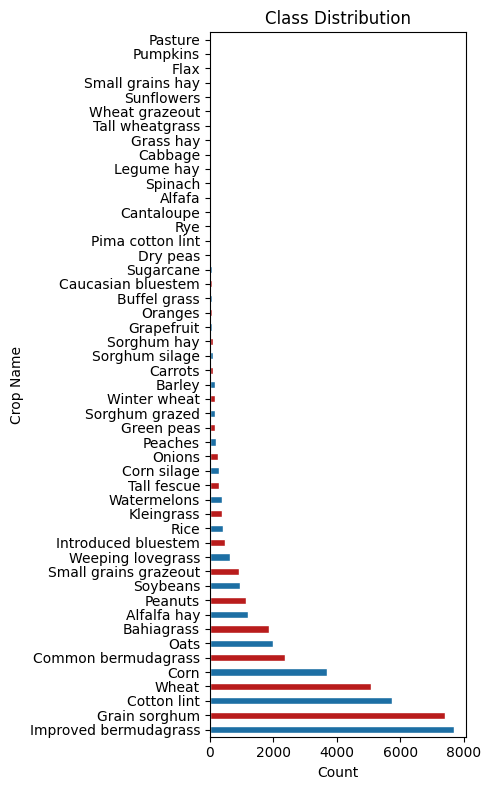

In [245]:
plt.figure(figsize=(5, 8))

# Change 'kind' to 'barh' for horizontal bars
df_soil['cropname'].value_counts().plot(
    kind='barh',
    color=['#1d6fa4', '#b91c1c'],
    edgecolor='white', 
    width=0.5
)

# Swap labels to match the new orientation
plt.title('Class Distribution', fontsize=12)
plt.xlabel('Count')       # Now the x-axis shows the count
plt.ylabel('Crop Name')   # Now the y-axis shows the crop names

plt.tight_layout()
plt.show()

#### Correlation matrix

In [246]:
# Select numeric colmns
num_cols = df_soil.select_dtypes(include=['int64', 'float64']).columns
print("Numeric features:", num_cols.tolist())

# Select categorical columns
cat_cols = df_soil.select_dtypes(include=['str', 'object']).columns
print("Categorical features:", cat_cols.tolist())

Numeric features: ['elev_r', 'slope_r', 'hzdepb_r', 'ph1to1h2o_r', 'om_r', 'ec_r', 'cec7_r', 'awc_r']
Categorical features: ['compname', 'taxorder', 'drainagecl', 'cropname']


In [247]:
# Make a correlation matrix
cm = df_soil[num_cols].corr()
print(cm)

               elev_r   slope_r  hzdepb_r  ph1to1h2o_r      om_r      ec_r  \
elev_r       1.000000 -0.068378 -0.061533     0.457961 -0.002216  0.083472   
slope_r     -0.068378  1.000000 -0.094847    -0.089381 -0.184970 -0.110577   
hzdepb_r    -0.061533 -0.094847  1.000000     0.141671 -0.004805  0.038575   
ph1to1h2o_r  0.457961 -0.089381  0.141671     1.000000  0.277338  0.199649   
om_r        -0.002216 -0.184970 -0.004805     0.277338  1.000000  0.057878   
ec_r         0.083472 -0.110577  0.038575     0.199649  0.057878  1.000000   
cec7_r      -0.024700 -0.128459  0.039625     0.458300  0.645033  0.161309   
awc_r        0.092748 -0.177678 -0.074996     0.298228  0.384092  0.013640   

               cec7_r     awc_r  
elev_r      -0.024700  0.092748  
slope_r     -0.128459 -0.177678  
hzdepb_r     0.039625 -0.074996  
ph1to1h2o_r  0.458300  0.298228  
om_r         0.645033  0.384092  
ec_r         0.161309  0.013640  
cec7_r       1.000000  0.387066  
awc_r        0.387066  1.

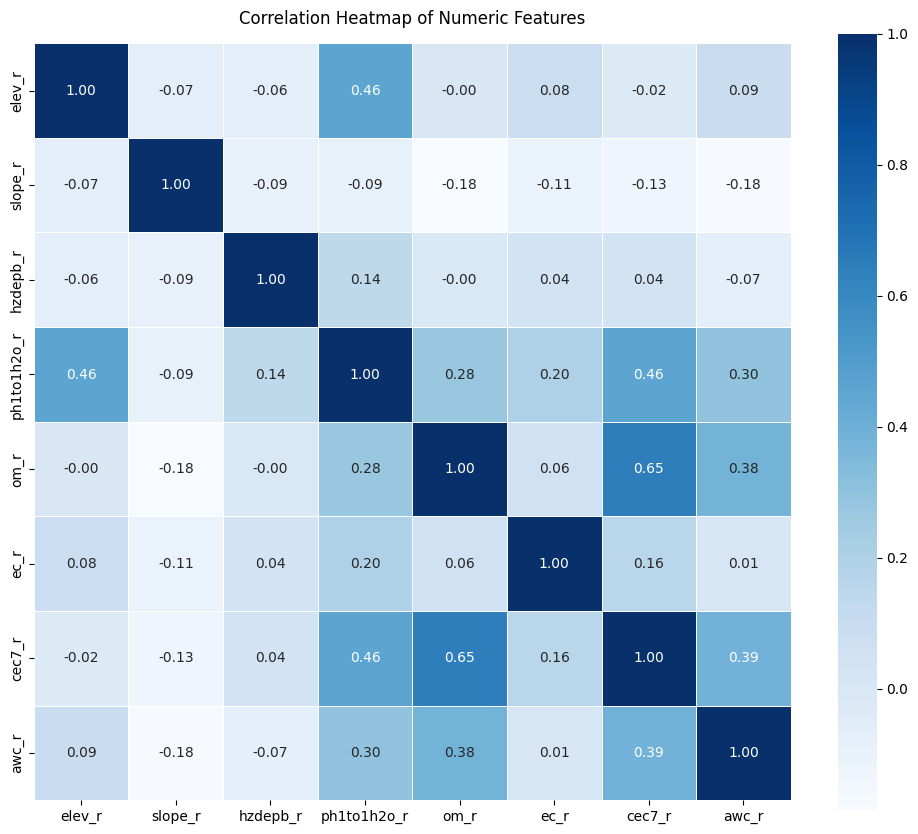

In [248]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    square=True,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=12, pad=14)
plt.tight_layout()
plt.show()

### Train and test split

In [249]:
X = df_soil.drop('cropname', axis=1)
y = df_soil['cropname']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

In [250]:
print(f"Training set  : {X_train.shape[0]} samples")
print(f"Test set      : {X_test.shape[0]} samples")

Training set  : 36003 samples
Test set      : 9001 samples


In [267]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['str', 'object']).columns
print(num_cols)
print(cat_cols)

Index(['elev_r', 'slope_r', 'hzdepb_r', 'ph1to1h2o_r', 'om_r', 'ec_r',
       'cec7_r', 'awc_r'],
      dtype='str')
Index(['compname', 'taxorder', 'drainagecl'], dtype='str')


#### Build preprocessing pipeline

In [269]:
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())

])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])


In [270]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
                         random_state=42))
])

In [276]:
pipeline.fit(X_train, y_train)
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

print(accuracy_score(y_train, y_train_pred))
print(accuracy_score(y_test, y_test_pred))

0.2917534649890287
0.056882568603488504


In [252]:
df_weather.head()

,month,precip_total_mm,tmax_avg_c,tmin_avg_c
0,1,68.904092,12.620515,0.145149
1,2,41.617366,18.198243,4.128925
2,3,60.824599,25.318835,9.548430
3,4,83.453419,27.084042,14.263100
4,5,166.870902,29.932103,17.432293


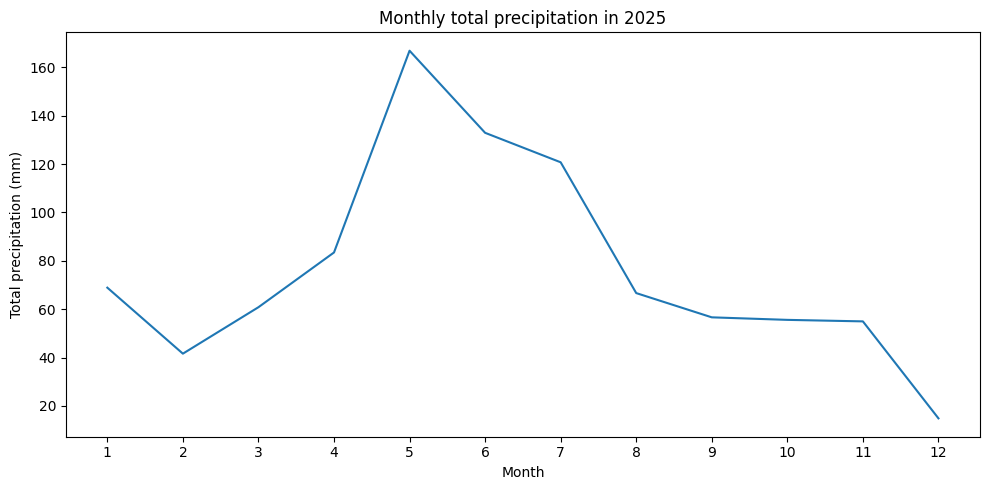

In [253]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=df_weather['month'], y=df_weather['precip_total_mm'])
plt.xticks(range(1, 13))
plt.title("Monthly total precipitation in 2025")
plt.xlabel("Month")
plt.ylabel("Total precipitation (mm)")
plt.tight_layout()
plt.show()